In [19]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
#extract dataset
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/kagglecatsanddogs_5340.zip"
extract_path = "/content/catsdogs"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")


Dataset Extracted Successfully!


In [21]:
#load images
import os
import cv2
import numpy as np

data = []
labels = []

cats_path = "/content/catsdogs/PetImages/Cat"
dogs_path = "/content/catsdogs/PetImages/Dog"

SIZE = 32

for img in os.listdir(cats_path)[:200]:
    try:
        path = os.path.join(cats_path, img)
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (SIZE, SIZE))
        data.append(image.flatten())
        labels.append(0)
    except:
        pass

for img in os.listdir(dogs_path)[:200]:
    try:
        path = os.path.join(dogs_path, img)
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (SIZE, SIZE))
        data.append(image.flatten())
        labels.append(1)
    except:
        pass

X = np.array(data) / 255.0
y = np.array(labels)

print("Dataset Shape:", X.shape)

Dataset Shape: (400, 1024)


In [22]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(320, 1024) (80, 1024)


In [23]:
#train svm
from sklearn.svm import SVC

model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")


Model Trained Successfully!


In [24]:
#accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6625


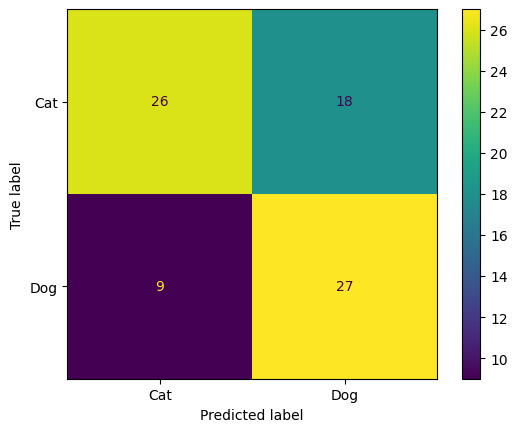

In [27]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Cat", "Dog"])
disp.plot()

plt.show()

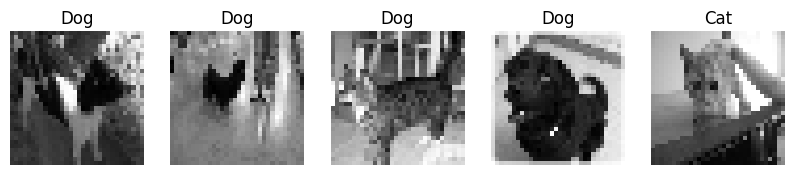

In [28]:
#sample prediction
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(32,32), cmap='gray')
    plt.title("Dog" if y_pred[i]==1 else "Cat")
    plt.axis('off')

plt.show()
